## **Modeling & Evaluation**

In [29]:
# Import library untuk model dan evaluasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengambil kembali data split dari Step 3
%store -r X_train X_test y_train y_test

print("Data berhasil diambil")
print(f"Training set: {X_train.shape[0]} sampel")
print(f"Testing set: {X_test.shape[0]} sampel")

# Inisialisasi Model Random Forest
# random_state=42 untuk hasil yang konsisten
# n_jobs=-1 untuk menggunakan semua core CPU (lebih cepat)
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

print("\nMemulai Training Model Random Forest...")
# Melatih model dengan data train
rf_model.fit(X_train, y_train)
print("\nModel berhasil dilatih (Training Selesai)!")

Data berhasil diambil
Training set: 1913 sampel
Testing set: 479 sampel

Memulai Training Model Random Forest...

Model berhasil dilatih (Training Selesai)!


### Prediksi Data Testing

In [30]:
# Melakukan prediksi pada data test
y_pred = rf_model.predict(X_test)

# Menampilkan 5 prediksi pertama vs nilai asli
print("5 Prediksi Pertama vs Nilai Asli:")
df_hasil = pd.DataFrame({'Prediksi': y_pred, 'Asli': y_test})
print(df_hasil.head())

5 Prediksi Pertama vs Nilai Asli:
      Prediksi  Asli
1167       4.0   4.0
1839       4.0   4.0
2122       4.0   4.0
1460       4.0   4.0
352        2.0   2.0


### Evaluasi Metrik (Accuracy & Report)

In [31]:
# Hitung Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print(f"AKURASI MODEL: {accuracy:.2%}") # Contoh: 85.00%
print("="*60)

# Classification Report (Detail per kelas)
print("\nLAPORAN KLASIFIKASI (Classification Report):")
print(classification_report(y_test, y_pred, zero_division=0))

AKURASI MODEL: 91.23%

LAPORAN KLASIFIKASI (Classification Report):
              precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        21
         1.0       0.82      0.87      0.85        54
         2.0       0.90      0.95      0.93        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.91       479
   macro avg       0.91      0.79      0.81       479
weighted avg       0.92      0.91      0.90       479



### Visualisasi Confusion Matrix

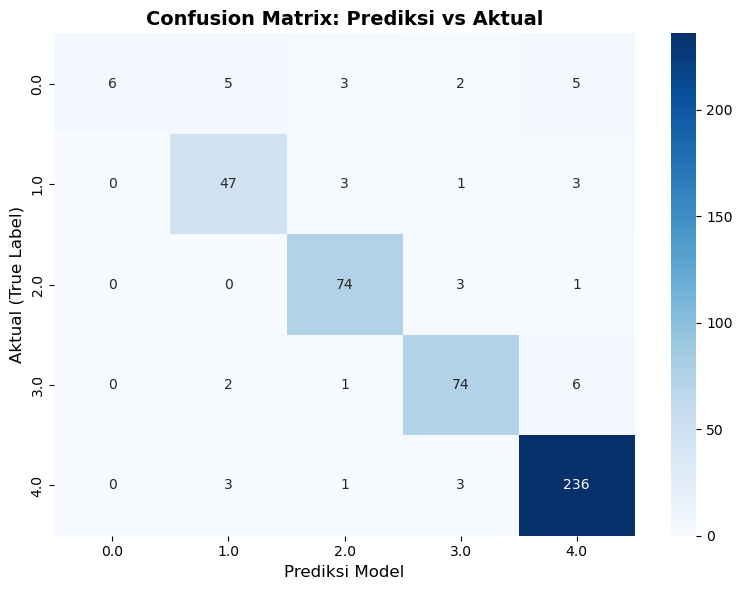


Insight Confusion Matrix:
Angka di diagonal utama (kiri atas ke kanan bawah) menunjukkan prediksi BENAR.
Semakin besar angka di luar diagonal, semakin sering model salah menebak kelas tersebut.


In [32]:
# Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()), 
            yticklabels=sorted(y_test.unique()))

plt.title('Confusion Matrix: Prediksi vs Aktual', fontsize=14, fontweight='bold')
plt.ylabel('Aktual (True Label)', fontsize=12)
plt.xlabel('Prediksi Model', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInsight Confusion Matrix:")
print("Angka di diagonal utama (kiri atas ke kanan bawah) menunjukkan prediksi BENAR.")
print("Semakin besar angka di luar diagonal, semakin sering model salah menebak kelas tersebut.")

### Feature Importance (Fitur Paling Berpengaruh)

C:\Users\MacTavish\AppData\Local\Temp\ipykernel_2612\108233457.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


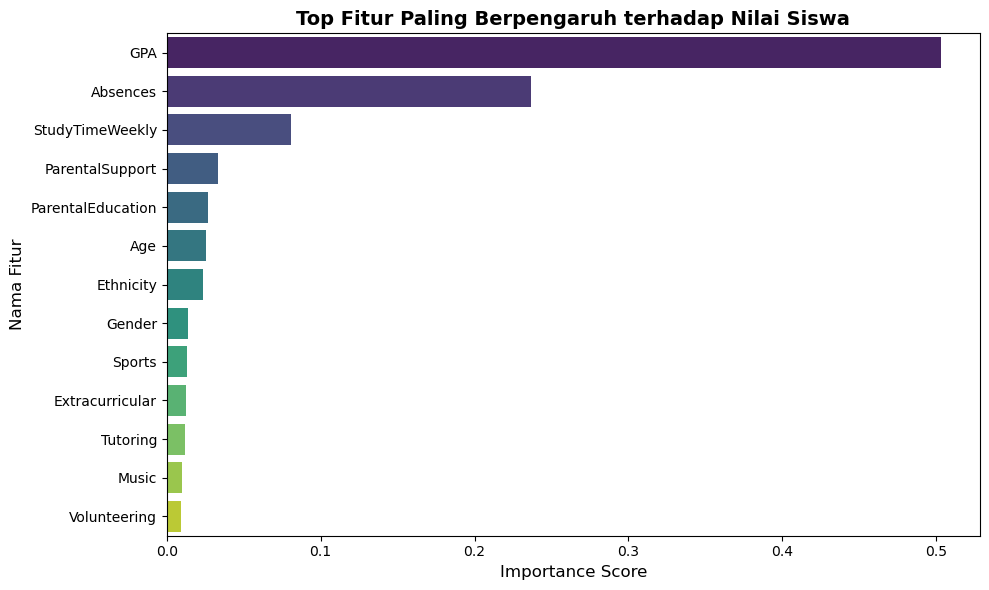

Top 3 Faktor Penentu Nilai Siswa:
        Feature  Importance
            GPA    0.503369
       Absences    0.236851
StudyTimeWeekly    0.081052


In [33]:
# Ambil importance dari model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Buat DataFrame untuk sorting
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi Top 10 Fitur
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Top Fitur Paling Berpengaruh terhadap Nilai Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 3 Faktor Penentu Nilai Siswa:")
print(df_importance.head(3).to_string(index=False))

In [36]:
df = pd.read_csv('../data/raw/Student_performance_data.csv')

print("="*70)
print("RINGKASAN HASIL ANALISIS")
print("="*70)
print(f"• Total Data: {len(df)} siswa")
print(f"• Fitur yang Digunakan: {X_train.shape[1]}")
print(f"• Akurasi Model: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"• Fitur Paling Berpengaruh: {df_importance.iloc[0]['Feature']}")
print(f"• Rekomendasi: Fokus pada {df_importance.iloc[0]['Feature']} untuk intervensi akademik")
print("="*70)

RINGKASAN HASIL ANALISIS
• Total Data: 2392 siswa
• Fitur yang Digunakan: 13
• Akurasi Model: 91.23%
• Fitur Paling Berpengaruh: GPA
• Rekomendasi: Fokus pada GPA untuk intervensi akademik


In [ ]:
# Simpan classification report ke JSON
from sklearn.metrics import classification_report
import json

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
with open('../outputs/model_metrics.json', 'w') as f:
    json.dump(report, f, indent=2)
print("Metrik evaluasi disimpan ke outputs/model_metrics.json")

Metrik evaluasi disimpan ke outputs/model_metrics.json


In [ ]:
import joblib

# Simpan model
joblib.dump(rf_model, '../outputs/student_performance_model.pkl')
print("Model disimpan untuk penggunaan berikutnya")

Model disimpan untuk penggunaan berikutnya
